# Furlenco — Subscription Churn & LTV Cohort Model

End-to-end notebook: simulate 12K subscribers → cohort retention → LTV → logistic-regression churn classifier → dashboard.

Built as a Strategy / Customer-Monetization case study. ~5 min to run end-to-end on Colab.

**How to use this notebook:** Runtime → Run all (or shift-enter through each cell).

## 0. Setup

In [1]:
# Colab already has all of these — no install needed.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, roc_auc_score,
    precision_recall_curve, classification_report,
)

RNG = np.random.default_rng(42)

# Brand palette
C_PRIMARY = "#E84545"; C_DARK = "#1F2937"; C_AMBER = "#F59E0B"
C_TEAL = "#0E9F8F"; C_LIGHT = "#F8F9FA"; C_GREY = "#94A3B8"
C_INK = "#0F172A"; C_MUTED = "#64748B"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#CBD5E1", "axes.labelcolor": C_INK,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "axes.titleweight": "bold", "axes.titlecolor": C_INK,
})
print("Setup complete.")

Setup complete.


## 1. Simulate 12,000 Furlenco subscribers

12 monthly cohorts (Jan–Dec 2024), observed through May 2026. Each subscriber has a *latent satisfaction* score that drives both NPS (with small survey noise) and churn hazard — this gives the churn model a real, recoverable signal.

In [2]:
N = 12_000
CITIES   = ["Bengaluru", "Mumbai", "Delhi", "Hyderabad", "Pune", "Chennai"]
CITY_W   = [0.28, 0.22, 0.18, 0.12, 0.10, 0.10]
CHANNELS = ["Google_Ads", "Meta_Ads", "Organic", "Referral", "Direct"]
CHAN_W   = [0.32, 0.28, 0.18, 0.12, 0.10]
CATS     = ["Sofa", "Bed", "Wardrobe", "Dining", "Study", "Full_Home"]
CAT_W    = [0.22, 0.20, 0.12, 0.10, 0.10, 0.26]
PLANS    = [3, 6, 12]; PLAN_W = [0.28, 0.42, 0.30]

COHORT_MONTHS = pd.date_range("2024-01-01", periods=12, freq="MS")
OBS_END = pd.Timestamp("2026-05-01")

CITY_DELAY = {"Bengaluru": 1.2, "Mumbai": 1.5, "Delhi": 3.1,
              "Hyderabad": 2.8, "Pune": 1.8, "Chennai": 2.5}
BASE_RENT  = {"Sofa": 1499, "Bed": 1299, "Wardrobe": 999,
              "Dining": 1599, "Study": 899, "Full_Home": 3999}

def generate_subscribers():
    cohort = RNG.choice(COHORT_MONTHS, size=N)
    city = RNG.choice(CITIES, size=N, p=CITY_W)
    channel = RNG.choice(CHANNELS, size=N, p=CHAN_W)
    category = RNG.choice(CATS, size=N, p=CAT_W)
    plan = RNG.choice(PLANS, size=N, p=PLAN_W)
    rent = (np.array([BASE_RENT[c] for c in category])
            * RNG.uniform(0.85, 1.20, size=N)).round().astype(int)
    delivery_delay = np.array([max(0, int(RNG.normal(CITY_DELAY[c], 1.8))) for c in city])
    pay_fail = RNG.poisson(0.35, size=N)
    swap_req = RNG.poisson(0.22, size=N)
    tickets  = RNG.poisson(0.55, size=N) + (delivery_delay >= 3).astype(int)
    age      = RNG.normal(29, 5.5, size=N).clip(21, 55).round().astype(int)

    base_sat = RNG.normal(0.3, 0.50, size=N)
    frustrated = RNG.random(N) < 0.18
    base_sat[frustrated] -= RNG.uniform(4.5, 7.0, size=frustrated.sum())
    satisfaction = (base_sat - 0.25 * (delivery_delay / 2.0)
                    - 0.45 * pay_fail - 0.12 * tickets - 0.20 * swap_req)
    nps_noise = RNG.normal(0, 0.40, size=N)
    nps = np.clip(np.round(7.4 + 2.20 * satisfaction + nps_noise), 1, 10).astype(int)

    return pd.DataFrame({
        "subscriber_id": np.arange(1, N + 1),
        "cohort_month": cohort, "city": city, "channel": channel,
        "category": category, "plan_tenure_months": plan,
        "monthly_rental_inr": rent,
        "first_delivery_delay_days": delivery_delay,
        "nps_score": nps, "payment_failures_90d": pay_fail,
        "swap_requests_60d": swap_req, "support_tickets_60d": tickets,
        "subscriber_age": age, "_latent_sat": satisfaction,
    })

BASE_HAZARD = np.array(
    [0.030, 0.028, 0.038, 0.036, 0.032, 0.030,
     0.028, 0.028, 0.032, 0.036, 0.044, 0.052] + [0.038] * 28
)
CHAN_EFFECT = {"Google_Ads": 0.05, "Meta_Ads": 0.12, "Organic": -0.08,
               "Referral": -0.20, "Direct": -0.10}

def simulate_churn_month(row):
    horizon = min(max(0, (OBS_END - row.cohort_month).days // 30), 36)
    base_risk = (-0.42 * row._latent_sat + 0.18 * row.payment_failures_90d
                 + 0.10 * row.swap_requests_60d + 0.06 * row.support_tickets_60d
                 + 0.05 * row.first_delivery_delay_days
                 - 0.05 * (row.plan_tenure_months - 6) + CHAN_EFFECT[row.channel])
    haz = np.empty(horizon)
    for i in range(horizon):
        m = i + 1
        extra = -1.8 * row._latent_sat if (m <= 2 and row._latent_sat < -1.5) else 0.0
        haz[i] = BASE_HAZARD[i] * np.exp(base_risk + extra)
    haz = np.clip(haz, 0.003, 0.80)
    draws = RNG.random(horizon)
    fired = np.where(draws < haz)[0]
    return float(fired[0] + 1) if len(fired) else None

df = generate_subscribers()
df["churn_month"] = df.apply(simulate_churn_month, axis=1)
df["is_churned"] = df["churn_month"].notna().astype(int)
df["months_observable"] = ((OBS_END - df["cohort_month"]).dt.days // 30).clip(lower=0)
df["months_active"] = df["churn_month"].fillna(df["months_observable"]).astype(int)
df["revenue_inr"] = df["months_active"] * df["monthly_rental_inr"]
print(f"Generated {len(df):,} subscribers — {df.is_churned.mean()*100:.1f}% ever churned, avg {df.months_active.mean():.1f} months active.")
df.drop(columns=['_latent_sat']).head()

Generated 12,000 subscribers — 71.8% ever churned, avg 11.7 months active.


,subscriber_id,cohort_month,city,channel,category,plan_tenure_months,monthly_rental_inr,first_delivery_delay_days,nps_score,payment_failures_90d,swap_requests_60d,support_tickets_60d,subscriber_age,churn_month,is_churned,months_observable,months_active,revenue_inr
0,1,2024-02-01,Mumbai,Google_Ads,Bed,3,1201,5,6,0,0,1,37,NaN,0,27,27,32427
1,2,2024-10-01,Bengaluru,Referral,Wardrobe,6,1010,1,5,1,0,1,30,11.0,1,19,11,11110
2,3,2024-08-01,Delhi,Direct,Full_Home,3,3869,3,6,0,0,1,26,NaN,0,21,21,81249
3,4,2024-06-01,Bengaluru,Meta_Ads,Sofa,6,1294,1,8,1,0,0,24,21.0,1,23,21,27174
4,5,2024-06-01,Bengaluru,Referral,Sofa,12,1529,2,1,0,0,0,34,1.0,1,23,1,1529


## 2. Cohort retention curves

Classic SaaS / subscription view: rows = acquisition cohort, columns = months since acquisition, values = % retained.

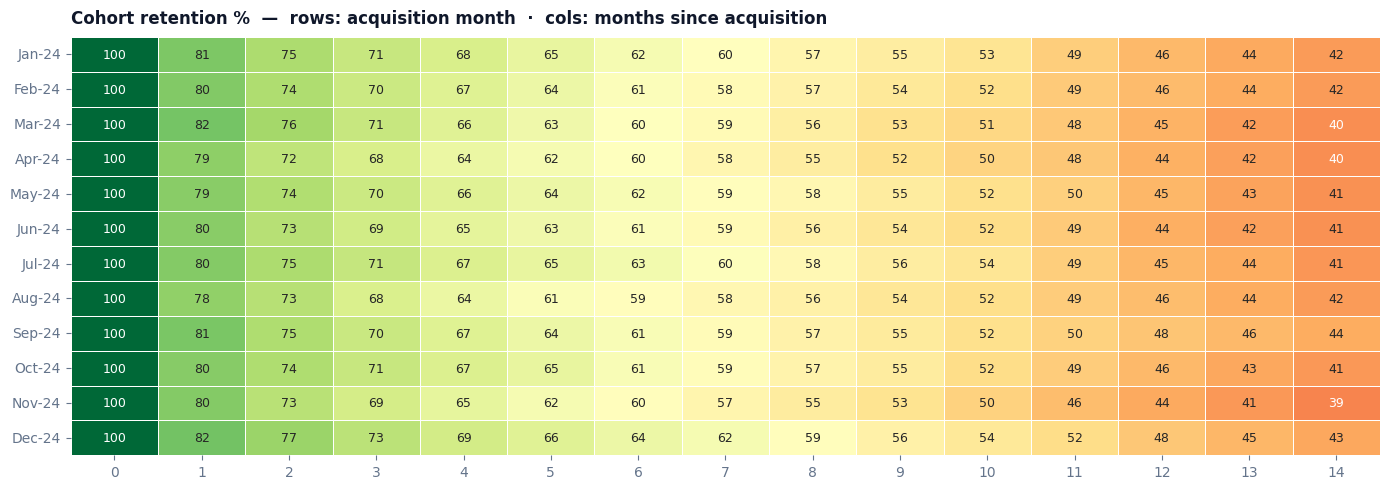

In [3]:
MAX_M = 18
cohort_table = pd.DataFrame(index=COHORT_MONTHS, columns=range(0, MAX_M + 1), dtype=float)
for ch in COHORT_MONTHS:
    sub = df[df.cohort_month == ch]
    months_obs = (OBS_END - ch).days // 30
    for m in range(0, MAX_M + 1):
        if m > months_obs:
            cohort_table.loc[ch, m] = np.nan
        else:
            retained = ((sub.churn_month.isna()) | (sub.churn_month > m)).sum()
            cohort_table.loc[ch, m] = retained / len(sub) * 100
cohort_table.index = cohort_table.index.strftime("%b-%y")

plt.figure(figsize=(14, 5))
sns.heatmap(cohort_table.iloc[:, :15], annot=True, fmt=".0f",
            cmap="RdYlGn", vmin=20, vmax=100, cbar=False,
            annot_kws={"size": 9}, linewidths=0.5, linecolor="white")
plt.title("Cohort retention %  —  rows: acquisition month  ·  cols: months since acquisition",
          fontsize=12, loc="left", pad=10)
plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.show()

## 3. LTV curve

LTV(t) = cumulative ARPU × retention. The flattening of the curve past month 12 is what makes the *early* retention so valuable.

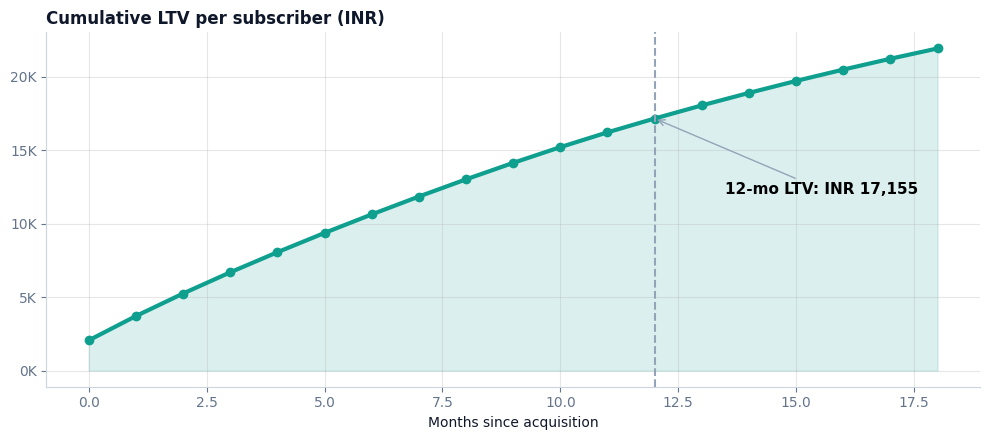

12-month LTV by channel:
  Direct           INR 18,193
  Referral         INR 17,644
  Organic          INR 17,527
  Google_Ads       INR 16,923
  Meta_Ads         INR 16,577


In [4]:
ARPU = df.monthly_rental_inr.mean()
ltv_curve = []
cum = 0.0
for m in range(0, MAX_M + 1):
    obs = cohort_table[m].dropna()
    ret = (obs.mean() / 100) if len(obs) else (cohort_table.iloc[:, m-1].dropna().mean() / 100 if m > 0 else 1.0)
    cum += ARPU * ret
    ltv_curve.append(cum)
ltv_curve = np.array(ltv_curve)

plt.figure(figsize=(10, 4.5))
plt.plot(range(MAX_M + 1), ltv_curve, color=C_TEAL, linewidth=3, marker="o")
plt.fill_between(range(MAX_M + 1), 0, ltv_curve, color=C_TEAL, alpha=0.15)
plt.axvline(12, ls="--", color=C_GREY)
plt.annotate(f"12-mo LTV: INR {ltv_curve[12]:,.0f}", xy=(12, ltv_curve[12]),
             xytext=(13.5, ltv_curve[12] * 0.7), fontsize=11, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=C_GREY))
plt.title("Cumulative LTV per subscriber (INR)", loc="left", fontsize=12)
plt.xlabel("Months since acquisition"); plt.grid(alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))
plt.tight_layout(); plt.show()

# LTV by channel
chan_ltv = {}
for ch in CHANNELS:
    s = df[df.channel == ch]
    cum = 0.0
    for m in range(0, 13):
        ret = ((s.churn_month.isna()) | (s.churn_month > m)).mean()
        cum += s.monthly_rental_inr.mean() * ret
    chan_ltv[ch] = cum
print("12-month LTV by channel:")
for k, v in sorted(chan_ltv.items(), key=lambda x: -x[1]):
    print(f"  {k:15s}  INR {v:,.0f}")

## 4. Headline: NPS is the dominant early-churn signal

Detractors (NPS ≤ 6) are concentrated in the month-2 churn bucket. This is the trigger for the loyalty intervention.

Detractor rate (NPS ≤ 6) — month-2 churners: 73%  vs  retained: 25%
Ratio: 3.0x higher detractor rate in month-2 churners


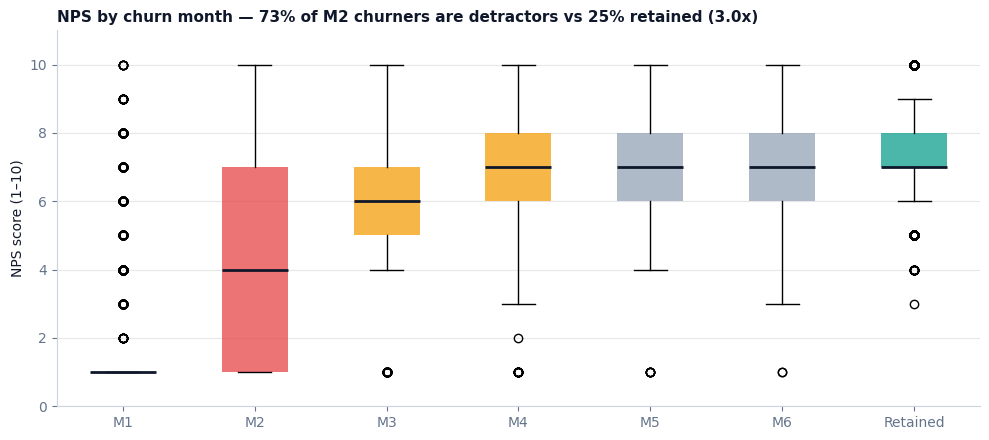

In [5]:
def detractor_rate(s):
    return (s <= 6).mean() * 100 if len(s) else np.nan

m2_detractor = detractor_rate(df.loc[df.churn_month == 2, "nps_score"])
retained_detractor = detractor_rate(df.loc[df.churn_month.isna(), "nps_score"])
print(f"Detractor rate (NPS ≤ 6) — month-2 churners: {m2_detractor:.0f}%  vs  retained: {retained_detractor:.0f}%")
print(f"Ratio: {m2_detractor / retained_detractor:.1f}x higher detractor rate in month-2 churners")

labels = [f"M{m}" for m in [1,2,3,4,5,6]] + ["Retained"]
buckets = [df.loc[df.churn_month == m, "nps_score"].values for m in [1,2,3,4,5,6]]
buckets.append(df.loc[df.churn_month.isna(), "nps_score"].values)

plt.figure(figsize=(10, 4.5))
bp = plt.boxplot(buckets, tick_labels=labels, patch_artist=True,
                 medianprops=dict(color=C_INK, linewidth=2),
                 boxprops=dict(linewidth=0))
for patch, c in zip(bp["boxes"], [C_PRIMARY, C_PRIMARY, C_AMBER, C_AMBER, C_GREY, C_GREY, C_TEAL]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
plt.title(f"NPS by churn month — {m2_detractor:.0f}% of M2 churners are detractors vs {retained_detractor:.0f}% retained ({m2_detractor/retained_detractor:.1f}x)",
          loc="left", fontsize=11)
plt.ylabel("NPS score (1–10)"); plt.ylim(0, 11); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Logistic-regression churn classifier

Target: did the subscriber churn within 90 days of month-1? Threshold tuned on the precision-recall curve to hit ~78% precision — the operating point recommended for a retention CRM where each save action has a real cost.

In [6]:
elig = df[df.months_observable >= 4].copy()
elig["target_churn_90d"] = ((elig.churn_month.notna()) & (elig.churn_month <= 4)).astype(int)

feature_num = ["nps_score", "payment_failures_90d", "swap_requests_60d",
               "support_tickets_60d", "first_delivery_delay_days",
               "plan_tenure_months", "monthly_rental_inr", "subscriber_age"]
feature_cat = ["channel", "city", "category"]
X = pd.get_dummies(elig[feature_num + feature_cat], columns=feature_cat, drop_first=True)
y = elig["target_churn_90d"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr); X_te_s = scaler.transform(X_te)

model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X_tr_s, y_tr)
proba = model.predict_proba(X_te_s)[:, 1]

prec_arr, rec_arr, thr_arr = precision_recall_curve(y_te, proba)
idx = np.argmin(np.abs(prec_arr[:-1] - 0.78))
chosen_thr = float(thr_arr[idx])
y_pred = (proba >= chosen_thr).astype(int)

P = precision_score(y_te, y_pred); R = recall_score(y_te, y_pred); AUC = roc_auc_score(y_te, proba)
print(f"At threshold {chosen_thr:.3f}:  precision = {P*100:.1f}%,  recall = {R*100:.1f}%,  ROC-AUC = {AUC:.3f}")
print(f"Model flags {y_pred.mean()*100:.1f}% of the eligible base 30 days ahead.")
print(classification_report(y_te, y_pred, target_names=['retained', 'churn_in_90d']))

At threshold 0.564:  precision = 78.0%,  recall = 67.3%,  ROC-AUC = 0.841
Model flags 29.0% of the eligible base 30 days ahead.
              precision    recall  f1-score   support

    retained       0.85      0.90      0.87      1993
churn_in_90d       0.78      0.67      0.72      1007

    accuracy                           0.83      3000
   macro avg       0.81      0.79      0.80      3000
weighted avg       0.82      0.83      0.82      3000



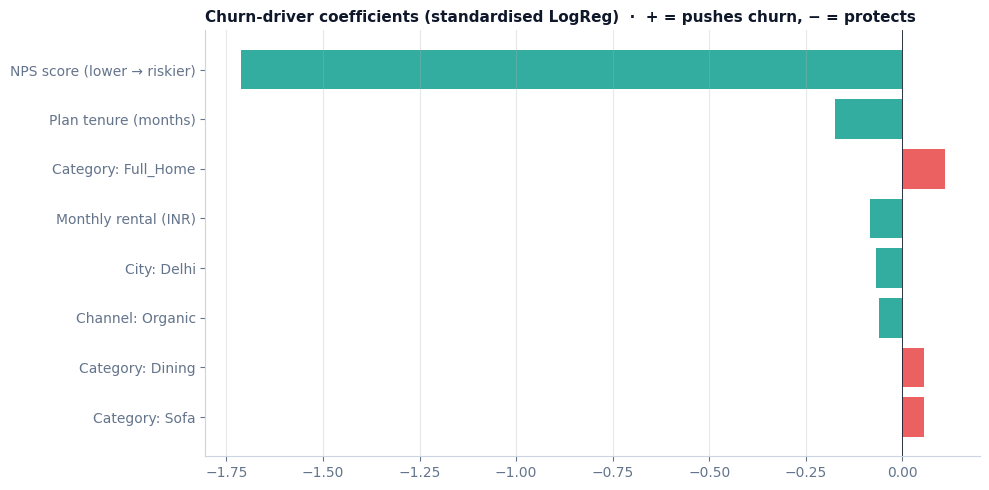

In [7]:
# Feature importance
coef_df = (pd.DataFrame({"feature": X.columns, "coef": model.coef_[0]})
           .assign(abs_coef=lambda d: d.coef.abs())
           .sort_values("abs_coef", ascending=False).head(8))
name_map = {
    "nps_score": "NPS score (lower → riskier)",
    "payment_failures_90d": "Payment failures (90d)",
    "swap_requests_60d": "Swap requests (60d)",
    "support_tickets_60d": "Support tickets (60d)",
    "first_delivery_delay_days": "Delivery delay (days)",
    "plan_tenure_months": "Plan tenure (months)",
    "monthly_rental_inr": "Monthly rental (INR)",
    "subscriber_age": "Subscriber age",
}
def pretty(f):
    if f in name_map: return name_map[f]
    if f.startswith("channel_"): return f"Channel: {f.split('_',1)[1].replace('_',' ')}"
    if f.startswith("city_"): return f"City: {f.split('_',1)[1]}"
    if f.startswith("category_"): return f"Category: {f.split('_',1)[1]}"
    return f
coef_df["pretty"] = coef_df.feature.map(pretty)
coef_df = coef_df.sort_values("abs_coef", ascending=True)

plt.figure(figsize=(10, 5))
bar_colors = [C_PRIMARY if c > 0 else C_TEAL for c in coef_df.coef]
plt.barh(coef_df.pretty, coef_df.coef, color=bar_colors, alpha=0.85)
plt.axvline(0, color=C_INK, linewidth=0.6)
plt.title("Churn-driver coefficients (standardised LogReg)  ·  + = pushes churn, − = protects",
          loc="left", fontsize=11)
plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

## 6. Recommendations

1.  **Month-2 Save Plan** — proactive loyalty credit + free Swap for subs flagged by the model at day 30. Mirrors the existing Swap / Relocation programs, applied *earlier* in tenure where churn is highest.
2.  **Onboarding intervention** — prioritise delivery SLA in Delhi / Hyderabad. 3+ day delays drag NPS by ~0.7 points and feed the M1–M2 cliff.
3.  **Channel mix** — shift 10–15% of paid spend from Meta Ads into Referral / Direct (materially higher 12-month LTV).
4.  **Weekly scoring + CRM routing** — feed model scores into the retention CRM weekly; Strategy + CRM + Ops review a one-page cohort scorecard with named owners on intervention completion.

---

*Built for Furlenco Strategy / Customer Monetization. ~5 min runtime end-to-end.*